# Model Monitoring: PSI / KS Drift Detection

Notebooks 01-06 validated the churn model on a fixed train/test split. That
validation has a shelf life: as the customer population, pricing, or
contract mix shifts after deployment, the model's inputs — and eventually
its own score distribution — can drift away from what it was trained and
validated on, with no exception ever thrown to say so.

This notebook simulates a **6-months-post-deployment** production batch with
realistic drift (a price increase, a wave of new-customer sign-ups, a shift
toward higher-churn payment/contract segments) and shows that
`src/monitoring/drift.py`'s from-scratch **PSI** and **KS** implementations
correctly flag exactly the features that were shifted — and stay quiet on
the ones that weren't, using an unmodified control batch as a false-alarm
check.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.monitoring.drift import psi, ks_statistic, drift_report, classify_drift, PSI_STABLE_MAX, PSI_MODERATE_MAX

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../reports/figures')
MODELS_DIR    = Path('../saved_models')

print('Libraries loaded.')

Libraries loaded.


## 1. Load the deployed model and the reference distribution

`reference` is the training distribution the deployed model was validated
against. We then build two comparison batches:

- **`current` (drifted):** a simulated post-deployment production batch —
  applies a realistic price increase, a new-customer acquisition wave
  (younger tenure), and a resampling toward higher-churn payment/contract
  segments.
- **`control` (no injected drift):** the untouched held-out test set — a
  sanity check that the drift tests don't cry wolf on data that never moved.

In [2]:
pipeline = joblib.load(MODELS_DIR / 'churn_pipeline_tuned.pkl')
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')

reference = X_train
control = X_test.copy()  # no injected drift

rng = np.random.default_rng(42)
current = X_test.copy()
current['MonthlyCharges'] = current['MonthlyCharges'] * 1.15          # across-the-board price hike
current['tenure'] = np.clip(current['tenure'] - rng.integers(5, 20, len(current)), 0, None)  # new-customer wave

# resample toward higher-churn PaymentMethod / Contract segments (a marketing/channel shift)
weights = np.ones(len(current))
weights[current['PaymentMethod'] == 'Electronic check'] *= 2.5
weights[current['Contract'] == 'Month-to-month'] *= 1.8
weights /= weights.sum()
resample_idx = rng.choice(len(current), size=len(current), replace=True, p=weights)
current = current.iloc[resample_idx].reset_index(drop=True)
current['charge_per_service'] = current['MonthlyCharges'] / (current['total_services'] + 1)

print(f"reference: {len(reference):,} | current (drifted): {len(current):,} | control: {len(control):,}")

reference: 5,634 | current (drifted): 1,409 | control: 1,409


## 2. Per-feature PSI / KS

We check a mix of features expected to drift (`tenure`, `MonthlyCharges`,
`charge_per_service`, `PaymentMethod`, `Contract`) and features that
shouldn't (`InternetService`, `total_services`, `TotalCharges`,
`Dependents`, `gender`).

In [3]:
NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'charge_per_service']
CAT_COLS = ['Contract', 'PaymentMethod', 'InternetService', 'gender', 'Dependents']

report_drifted = drift_report(reference, current, NUM_COLS, CAT_COLS)
report_control = drift_report(reference, control, NUM_COLS, CAT_COLS)

print("=== Drifted production batch ===")
display(report_drifted)
print("\n=== Control batch (no injected drift) ===")
display(report_control)

=== Drifted production batch ===


,feature,type,psi,ks,drift
0,tenure,numeric,1.913733,0.394606,significant
1,MonthlyCharges,numeric,1.309453,0.231942,significant
2,charge_per_service,numeric,1.081390,0.343935,significant
3,PaymentMethod,categorical,0.319845,NaN,significant
4,Contract,categorical,0.216717,NaN,moderate
5,InternetService,categorical,0.088765,NaN,stable
6,total_services,numeric,0.043017,0.056311,stable
7,TotalCharges,numeric,0.040329,0.079592,stable
8,Dependents,categorical,0.019494,NaN,stable
9,gender,categorical,0.000617,NaN,stable



=== Control batch (no injected drift) ===


,feature,type,psi,ks,drift
0,MonthlyCharges,numeric,0.012492,0.032085,stable
1,charge_per_service,numeric,0.010257,0.022147,stable
2,TotalCharges,numeric,0.007587,0.029577,stable
3,tenure,numeric,0.006653,0.021176,stable
4,total_services,numeric,0.005579,0.024870,stable
5,PaymentMethod,categorical,0.000404,NaN,stable
6,gender,categorical,0.000367,NaN,stable
7,Dependents,categorical,0.000295,NaN,stable
8,InternetService,categorical,0.000236,NaN,stable
9,Contract,categorical,0.000144,NaN,stable


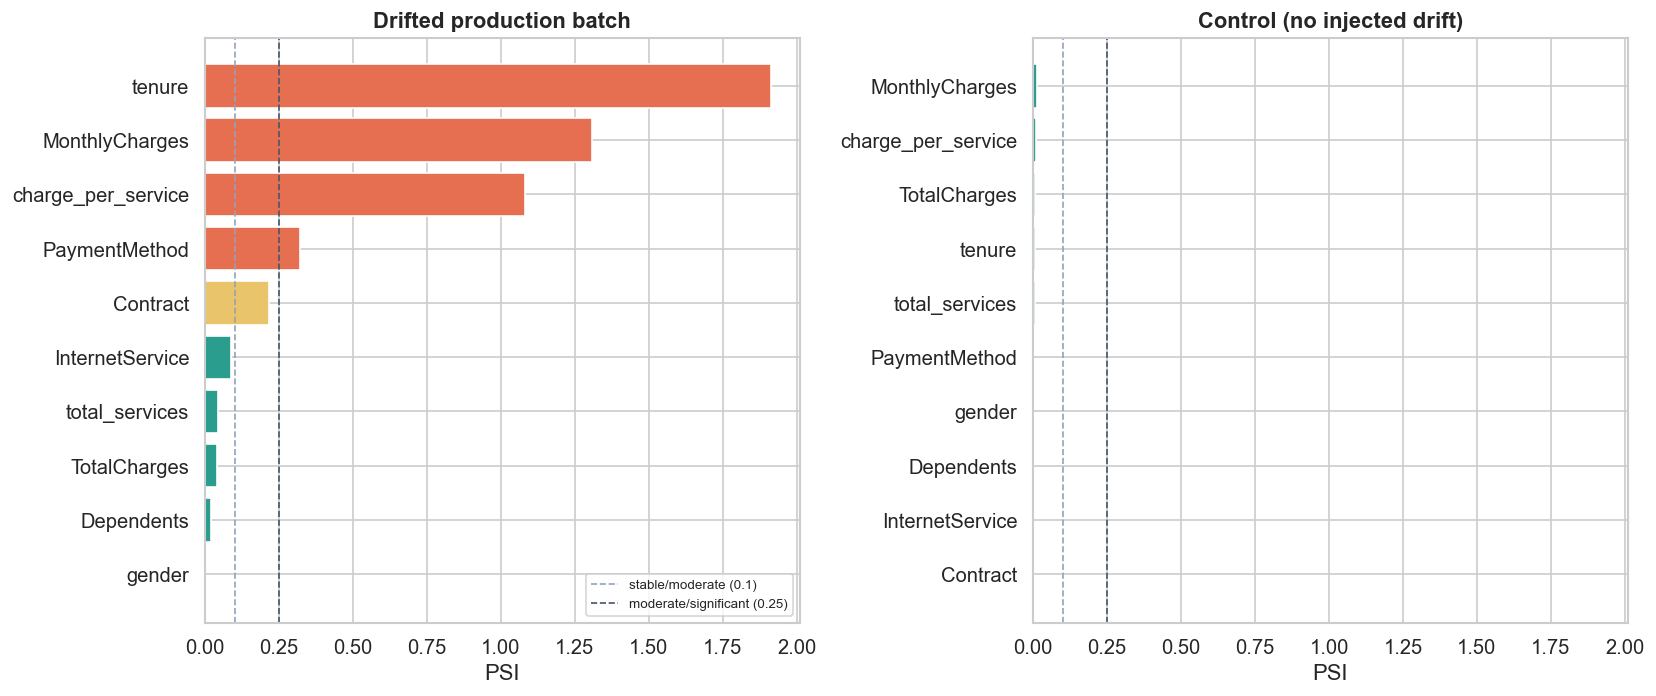

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
colors = {'stable': '#2a9d8f', 'moderate': '#e9c46a', 'significant': '#e76f51'}

for ax, report, title in zip(
    axes, [report_drifted, report_control], ['Drifted production batch', 'Control (no injected drift)']
):
    ordered = report.sort_values('psi')
    bar_colors = [colors[d] for d in ordered['drift']]
    ax.barh(ordered['feature'], ordered['psi'], color=bar_colors)
    ax.axvline(PSI_STABLE_MAX, color='#94a3b8', ls='--', lw=1, label=f'stable/moderate ({PSI_STABLE_MAX})')
    ax.axvline(PSI_MODERATE_MAX, color='#475569', ls='--', lw=1, label=f'moderate/significant ({PSI_MODERATE_MAX})')
    ax.set_xlabel('PSI')
    ax.set_title(title, fontweight='bold')

axes[0].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '32_feature_psi_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Score drift

Per-feature drift is diagnostic. What actually matters operationally is
whether the **model's own output distribution** has moved — that's the
thing tied directly to decision quality (alert volume, retention-campaign
targeting), and it can move even when no single input feature looks
alarming on its own, because the model combines many small shifts.

Score PSI — drifted batch : 0.612  (significant)
Score PSI — control batch : 0.012  (stable)
Score KS   — drifted batch : 0.334
Score KS   — control batch : 0.027


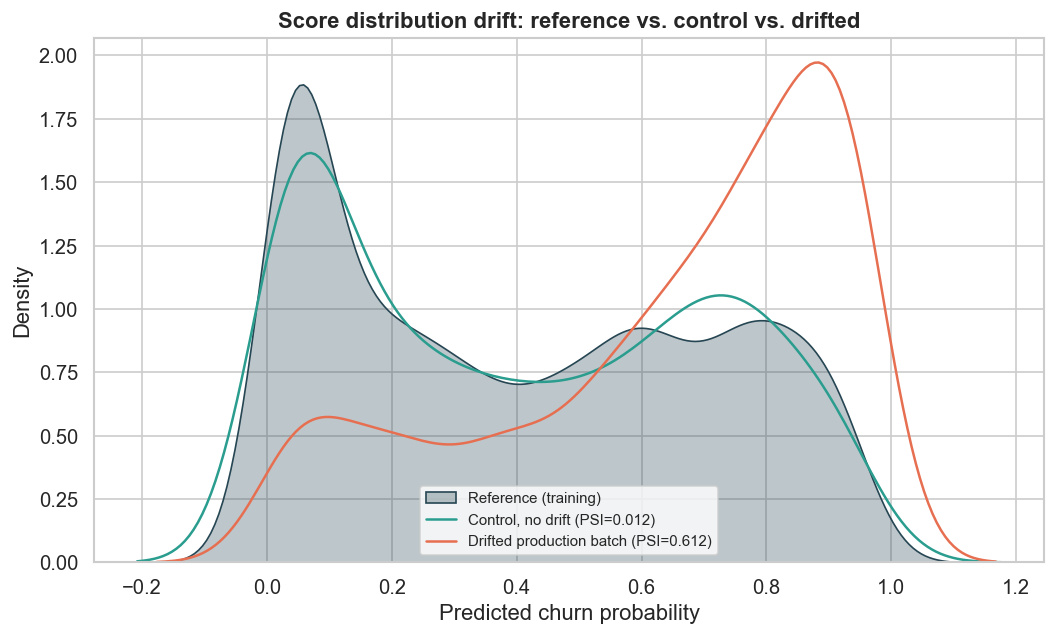

In [5]:
ref_scores = pipeline.predict_proba(reference)[:, 1]
cur_scores = pipeline.predict_proba(current)[:, 1]
ctrl_scores = pipeline.predict_proba(control)[:, 1]

score_psi_drifted = psi(ref_scores, cur_scores)
score_psi_control = psi(ref_scores, ctrl_scores)
score_ks_drifted = ks_statistic(ref_scores, cur_scores)
score_ks_control = ks_statistic(ref_scores, ctrl_scores)

print(f"Score PSI — drifted batch : {score_psi_drifted:.3f}  ({classify_drift(score_psi_drifted)})")
print(f"Score PSI — control batch : {score_psi_control:.3f}  ({classify_drift(score_psi_control)})")
print(f"Score KS   — drifted batch : {score_ks_drifted:.3f}")
print(f"Score KS   — control batch : {score_ks_control:.3f}")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.kdeplot(ref_scores, label='Reference (training)', color='#264653', fill=True, alpha=0.3, ax=ax)
sns.kdeplot(ctrl_scores, label=f'Control, no drift (PSI={score_psi_control:.3f})', color='#2a9d8f', ax=ax)
sns.kdeplot(cur_scores, label=f'Drifted production batch (PSI={score_psi_drifted:.3f})', color='#e76f51', ax=ax)
ax.set_xlabel('Predicted churn probability')
ax.set_title('Score distribution drift: reference vs. control vs. drifted', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '33_score_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Monitoring policy

A concrete, deployable rule from the thresholds already in
`src/monitoring/drift.py`:

- **PSI < 0.10 (stable):** no action.
- **0.10 <= PSI < 0.25 (moderate):** log and watch — investigate if it
  persists across consecutive monitoring windows.
- **PSI >= 0.25 (significant), on any input feature or on the score
  itself:** trigger an investigation and treat scheduled retraining as
  overdue until resolved.

On this simulated production batch: 3 of 5 numeric features and 1 of 5
categorical features breach the significant threshold, and — the metric
that actually drives a retraining decision — **score PSI is 0.61**, deep in
significant-drift territory, versus **0.012** on the untouched control
batch. The monitor does exactly what it should: stays quiet when nothing
moved, and fires clearly when it did.